In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data_day2.csv')

In [3]:
import pandas as pd

# Sort to ensure chronological order
df = df.sort_values('recording_time_ns').reset_index(drop=True)

# Define the maximum expected gap between rows within the same experiment
# (e.g., 1e9 nanoseconds = 1 second)
threshold_ns = 1e9 

# True where a new block starts, False otherwise
is_new_experiment = df['recording_time_ns'].diff() > threshold_ns

# Cumulative sum assigns a monotonically increasing integer to each contiguous block
df['experiment_id'] = is_new_experiment.cumsum()

# Split into a list of DataFrames
experiment_dfs = [group for _, group in df.groupby('experiment_id')]

In [14]:
for idx, df in enumerate(experiment_dfs):
    df.to_csv(f'day2/experiment{idx+1}.csv')

In [4]:
experiment_idx = 3
experiment_data = df[df['experiment_id'] == experiment_idx]
experiment_data

,recording_time_ns,dt,wind_enabled,pos_x,pos_y,pos_z,pos_roll,pos_pitch,pos_yaw,targetpos_x,targetpos_y,targetpos_z,targetpos_yaw,control_vel_x,control_vel_y,control_vel_z,control_vel_yaw,experiment_id
718,1777301073524708136,1.777301e+09,False,-0.691827,0.606689,0.812606,-0.023825,0.038757,-0.040221,-2.0,0.0,2.0,0.0,-0.750000,-0.750000,0.712436,0.024133,3
719,1777301073639532546,1.149750e-01,False,-0.694301,0.606138,0.813823,-0.028194,0.060869,-0.030130,-2.0,0.0,2.0,0.0,-0.750000,-0.385487,0.711706,0.018078,3
720,1777301073720554993,8.076715e-02,False,-0.699001,0.606366,0.815440,-0.030914,0.082047,-0.026327,-2.0,0.0,2.0,0.0,-0.750000,-0.384627,0.710736,0.015796,3
721,1777301073832646306,1.123860e-01,False,-0.702930,0.605818,0.816063,-0.023531,0.071857,-0.025771,-2.0,0.0,2.0,0.0,-0.750000,-0.381692,0.710362,0.015463,3
722,1777301073921039066,8.819675e-02,False,-0.705396,0.605869,0.816162,-0.034414,0.080358,-0.018475,-2.0,0.0,2.0,0.0,-0.750000,-0.377830,0.710303,0.011085,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
931,1777301094897747492,9.669614e-02,False,-2.857928,-0.643259,2.537116,-0.092857,-0.047015,2.186708,-3.0,-1.0,3.0,1.5,-0.066651,0.071633,0.277730,-0.412025,3
932,1777301094973359168,7.561707e-02,False,-2.877539,-0.680817,2.550654,-0.099422,-0.048668,2.170943,-3.0,-1.0,3.0,1.5,-0.037520,0.020433,0.269607,-0.402566,3
933,1777301095079246149,1.056650e-01,False,-2.894733,-0.714433,2.560109,-0.094304,-0.064369,2.134011,-3.0,-1.0,3.0,1.5,-0.056518,0.052650,0.263934,-0.380407,3
934,1777301095179003472,9.987020e-02,False,-2.906206,-0.744992,2.573541,-0.092984,-0.064727,2.119676,-3.0,-1.0,3.0,1.5,-0.040835,0.050545,0.255875,-0.371805,3


In [5]:
print(f'{1776697177697 / 0.02:.1e}')

8.9e+13


In [6]:
experiment_data['dt']

718    1.777301e+09
719    1.149750e-01
720    8.076715e-02
721    1.123860e-01
722    8.819675e-02
           ...     
931    9.669614e-02
932    7.561707e-02
933    1.056650e-01
934    9.987020e-02
935    1.019959e-01
Name: dt, Length: 218, dtype: float64

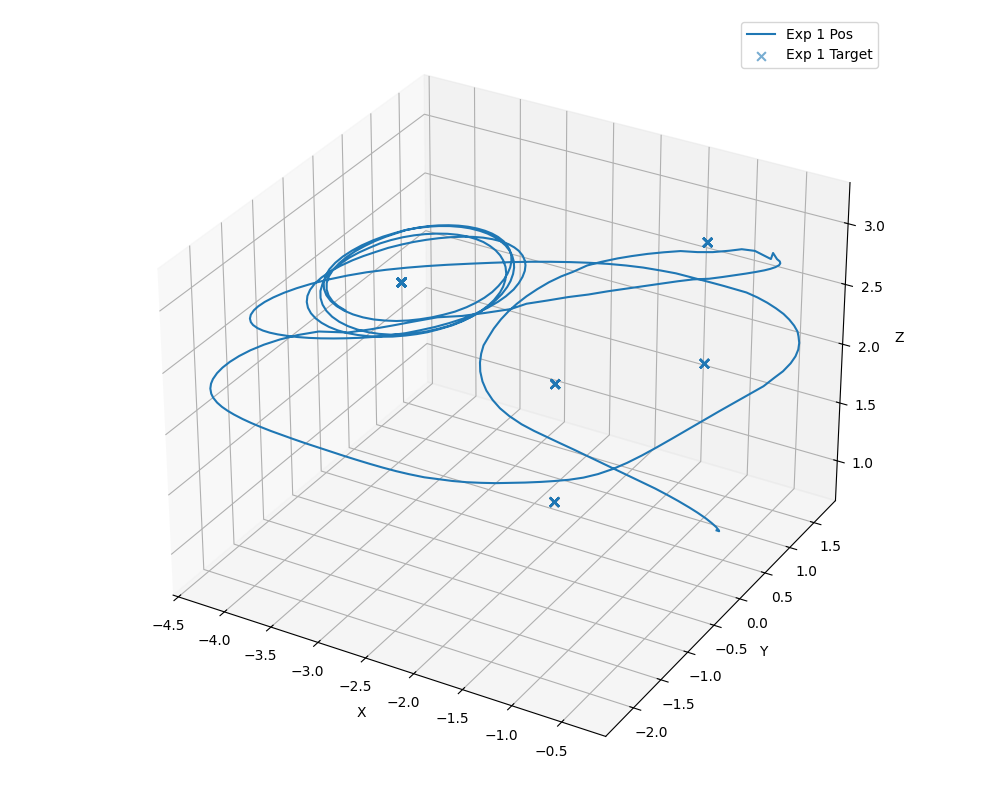

In [13]:
%matplotlib widget
import matplotlib.pyplot as plt

def plot_trajectories_3d(experiment_dfs):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, df in enumerate(experiment_dfs):
        line = ax.plot(
            df['pos_x'], 
            df['pos_y'], 
            df['pos_z'], 
            label=f'Exp {i+1} Pos'
        )
        
        ax.scatter(
            df['targetpos_x'], 
            df['targetpos_y'], 
            df['targetpos_z'], 
            label=f'Exp {i+1} Target',
            color=line[0].get_color(),
            marker='x',
            s=40,
            alpha=0.6
        )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_trajectories_3d(experiment_dfs[6:7])